1\. Environment Setup
---------------------

The authors utilized a Linux-based server with NVIDIA RTX GPUs. For this replication, we use **Detectron2**, a standard library for object detection research.

**Kaggle Note:** We install Detectron2 from source to ensure compatibility with Kaggle's pre-installed PyTorch version. We also ensure pyyaml is pinned to prevent dependency conflicts.

In [5]:
# Installation (Uncomment if needed)
# !pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu111/torch1.9/index.html

!pip install git+https://github.com/facebookresearch/detectron2.git

import os
import copy
import torch
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image

# Detectron2 imports
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, default_setup
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader
from detectron2.data import transforms as T
from detectron2.data import detection_utils as utils
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.structures import BoxMode

# Define Output Directory for Kaggle (Writable path)
OUTPUT_DIR = "/kaggle/working/output/naive_ddl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Using Torch version: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-btp8i6qk
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-btp8i6qk
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
Using Torch version: 2.8.0+cu126 | CUDA available: True


2\. Dataset Registration
------------------------

As per **Section 3.1**, the dataset consists of 5,900 images of paprika plants. We follow the paper's split:

*   **70% Training**
    
*   **10% Validation**
    
*   **20% Testing**
    

The DDL unit focuses on 6 abnormality categories found in the Paprika dataset.

In [6]:
# 6 Classes from the dataset README
# Note: Ensure this order matches the ID (0-5) in the YOLO .txt files.
# Usually YOLO starts at 0. Check your _classes.txt if avail.
CLASS_NAMES = [
    "blossom_end_rot",
    "graymold",
    "powdery_mildew",
    "spider_mite",
    "spotting_disease",
    "snails_and_slugs"
]

# === ADJUST THIS PATH ===
# Based on your screenshot, it is likely:
# /kaggle/input/paprika-dataset/data
# OR /kaggle/input/{your-dataset-name}/data
DATASET_ROOT = "/kaggle/input/datasets/tijesu26/paprika-dataset/data" 

def get_paprika_dicts(img_dir, label_dir):
    """
    Parses YOLO format dataset for Detectron2.
    """
    dataset_dicts = []
    # Find all images (support jpg and png)
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png"))
    
    print(f"Found {len(image_files)} images in {img_dir}")
    
    for idx, img_path in enumerate(image_files):
        record = {}
        
        # 1. Get Image Dimensions (Needed for YOLO relative -> absolute conversion)
        # We use PIL to lazy load just the size (faster than reading full image)
        with Image.open(img_path) as img:
            width, height = img.size
            
        record["file_name"] = img_path
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width
        
        # 2. Find Corresponding Label File
        # YOLO structure: images/file.jpg -> labels/file.txt
        filename = os.path.basename(img_path)
        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(label_dir, label_filename)
        
        objs = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5: continue
                
                # YOLO: class_id, center_x, center_y, width, height (Normalized)
                class_id = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                
                # Conversion to Absolute XYXY
                abs_cx = cx * width
                abs_cy = cy * height
                abs_w = w * width
                abs_h = h * height
                
                x_min = abs_cx - (abs_w / 2)
                y_min = abs_cy - (abs_h / 2)
                x_max = abs_cx + (abs_w / 2)
                y_max = abs_cy + (abs_h / 2)
                
                obj = {
                    "bbox": [x_min, y_min, x_max, y_max],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "category_id": class_id,
                }
                objs.append(obj)
        
        record["annotations"] = objs
        dataset_dicts.append(record)
        
    return dataset_dicts

def register_paprika_datasets():
    # Register Train and Valid based on folder structure
    splits = ["train", "valid"]
    
    for split in splits:
        name = f"paprika_{split}"
        img_dir = os.path.join(DATASET_ROOT, split, "images")
        label_dir = os.path.join(DATASET_ROOT, split, "labels")
        
        # Only register if path exists
        if os.path.exists(img_dir):
            DatasetCatalog.register(name, lambda d=img_dir, l=label_dir: get_paprika_dicts(d, l))
            MetadataCatalog.get(name).set(thing_classes=CLASS_NAMES)
            print(f"Successfully Registered: {name}")
        else:
            print(f"Warning: Directory not found: {img_dir}")

# Clear previous registrations if re-running
DatasetCatalog.clear()
register_paprika_datasets()

Successfully Registered: paprika_train
Successfully Registered: paprika_valid


Found 10342 images in /kaggle/input/datasets/tijesu26/paprika-dataset/data/train/images


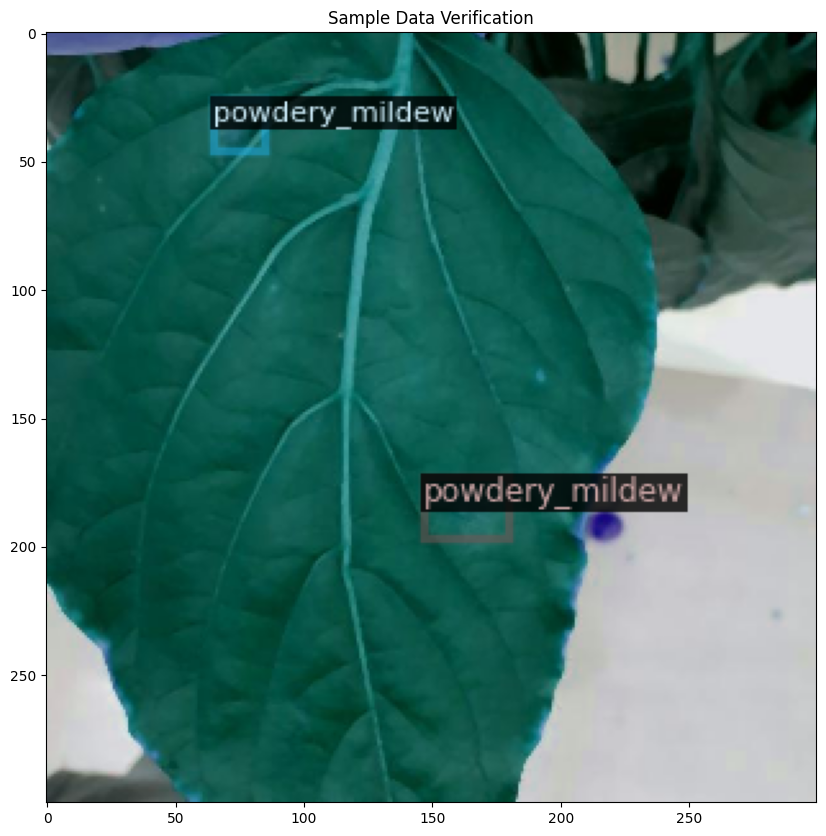

In [7]:
# Verification
if "paprika_train" in DatasetCatalog.list():
    dataset_dicts = DatasetCatalog.get("paprika_train")
    if len(dataset_dicts) > 0:
        d = dataset_dicts[20]
        img = utils.read_image(d["file_name"], format="BGR")
        visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("paprika_train"), scale=0.5)
                
        # === REDUCE TEXT SIZE ===
        # Manually override the calculated font size
        # Try values between 10 (small) and 25 (large)
        # visualizer._default_font_size = 15
        
        out = visualizer.draw_dataset_dict(d)
        plt.figure(figsize=(10, 10))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.title("Sample Data Verification")
        plt.show()
    else:
        print("Dataset registered but no images found.")

## 3. Augmentation Strategy

We implement the specific augmentations mentioned in **Table 4** of the paper.
The authors noted that *Color Temperature* and *Noise* reduced performance, while *Geometric* transforms improved it.

**Implemented Transforms:**
1.  **Random Flip:** Probability 0.9 (Horizontal).
2.  **Scale/Resize:** Table 4 lists `Scale x=[0.8, 1.2]`. In Detectron2, we implement this via `ResizeShortestEdge` with a range of sizes to simulate multi-scale training around the 1024px baseline.


In [8]:
def custom_mapper(dataset_dict):
    """
    Custom mapper to implement Table 4 augmentations.
    """
    dataset_dict = copy.deepcopy(dataset_dict)
    
    # Read image
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    
    # Baseline input size from Table 5 is 1024x1024
    # We create a range [0.8 * 1024, 1.2 * 1024] -> [819, 1228]
    min_size_range = (820, 1220) 
    
    transform_list = [
        # Table 4: Random Flip (prob=0.9)
        T.RandomFlip(prob=0.9, horizontal=True, vertical=False),
        
        # Table 4: Scale [0.8, 1.2]
        # We sample the shortest edge from the range to achieve scaling
        T.ResizeShortestEdge(short_edge_length=min_size_range, max_size=1333, sample_style='range'),
    ]
    
    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    # Apply transforms to annotations (bounding boxes)
    if "annotations" in dataset_dict:
        annos = [
            utils.transform_instance_annotations(obj, transforms, image.shape[:2])
            for obj in dataset_dict.pop("annotations")
            if obj.get("iscrowd", 0) == 0
        ]
        instances = utils.annotations_to_instances(annos, image.shape[:2])
        dataset_dict["instances"] = utils.filter_empty_instances(instances)
    
    return dataset_dict

### 3.1 Custom Trainer Definition

# We subclass `DefaultTrainer` to hook in our `custom_mapper`.

class NaiveDDLTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        # Swap standard loader for our custom mapper
        return build_detection_train_loader(cfg, mapper=custom_mapper)

## 4. Model Configuration (Naïve DDL)
  - **Optimizer:** SGD
  - **Momentum:** 0.9
  - **Base LR:** 0.08 (with Cosine Decay)
  - **Weight Decay:** 0.0005
  - **Batch Size:** 16
  - **Max Iterations:** 100,000

<!-- end list -->

In [9]:
def setup_cfg():
    cfg = get_cfg()
    
    # 1. Architecture: Faster R-CNN R50 FPN (Matches Table 5 Naive Framework)
    cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
    
    # 2. Dataset Registry (Updated to match the split names we registered)
    cfg.DATASETS.TRAIN = ("paprika_train",)
    cfg.DATASETS.TEST = ("paprika_valid",) # Using 'valid' as test
    cfg.DATALOADER.NUM_WORKERS = 2  
    
    # 3. Solver / Training Config (Table 3)
    # Note: 16 batch size requires high VRAM. On Kaggle P100 (16GB), use 4 or 8.
    # We scale LR accordingly: 0.08 is for batch 16. If batch 4, LR -> 0.02
    cfg.SOLVER.IMS_PER_BATCH = 4        
    cfg.SOLVER.BASE_LR = 0.02           
    
    cfg.SOLVER.MOMENTUM = 0.9
    cfg.SOLVER.WEIGHT_DECAY = 0.0005
    cfg.SOLVER.MAX_ITER = 10000          # Reduced for Kaggle Demo (Paper: 100000)
    cfg.SOLVER.WARMUP_ITERS = 1000      # 0-1K Warmup
    
    # 4. Learning Rate Scheduler
    cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
    
    # 5. Input Resolution (Table 5: 1024x1024)
    cfg.INPUT.MIN_SIZE_TRAIN = (1024,)
    cfg.INPUT.MAX_SIZE_TRAIN = 1024
    cfg.INPUT.MIN_SIZE_TEST = 1024
    cfg.INPUT.MAX_SIZE_TEST = 1024
    
    # 6. Model Heads
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512 
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6  # 6 Paprika anomalies
    
    # 7. Output
    cfg.OUTPUT_DIR = OUTPUT_DIR
    
    return cfg

cfg = setup_cfg()

## 5\. Training Loop

We initialize the custom trainer and start the process.

In [ ]:
# Initialize the trainer with our custom mapper
trainer = NaiveDDLTrainer(cfg)

# Load ImageNet pretrained weights (standard for D2)
trainer.resume_or_load(resume=False)

# Start Training
print(f"Starting Training: {datetime.now()}")
print(f"Configured for {cfg.SOLVER.MAX_ITER} iterations.")

In [ ]:
# Uncomment below to run training
trainer.train()

Running Quantitative Evaluation (mAP)...
Found 15 images in /kaggle/input/datasets/tijesu26/paprika-dataset/data/valid/images
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.429
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.747
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.474
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.280
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.307
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.735
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.204
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.456
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.456
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] =

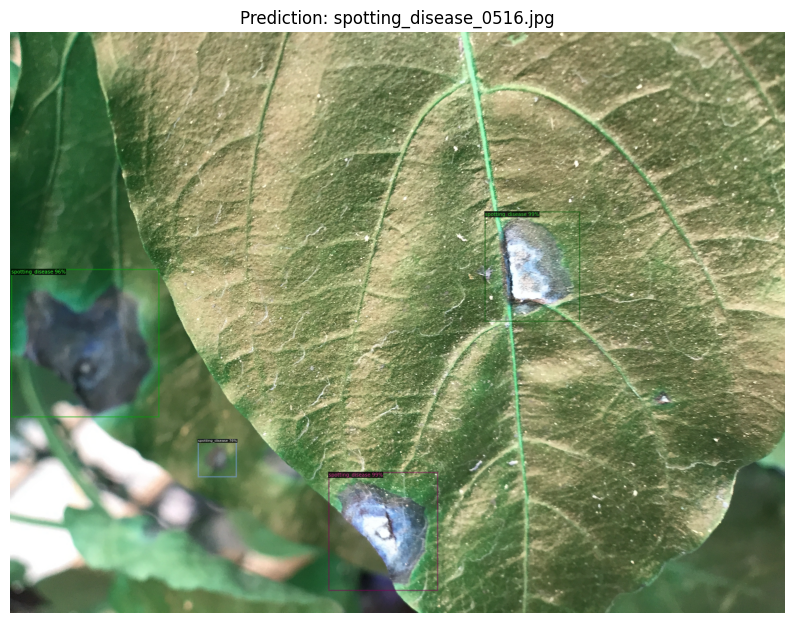

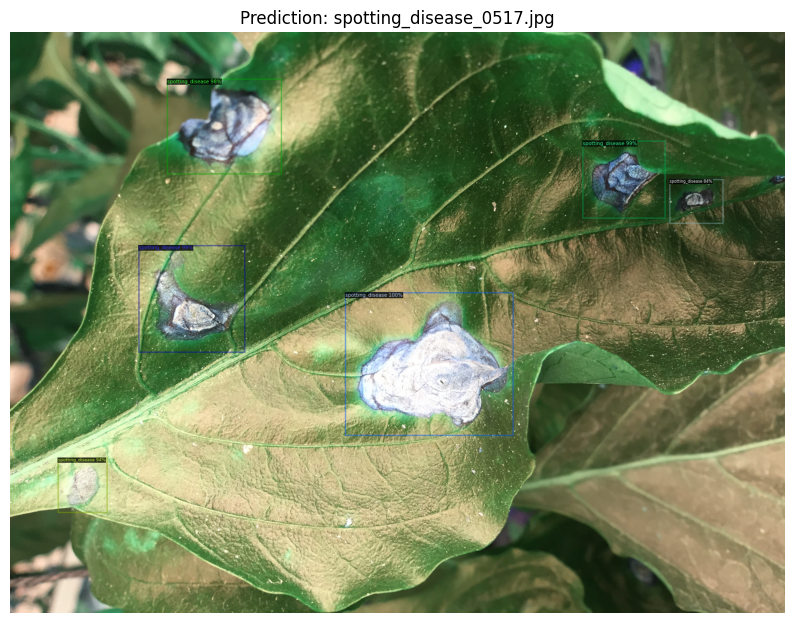

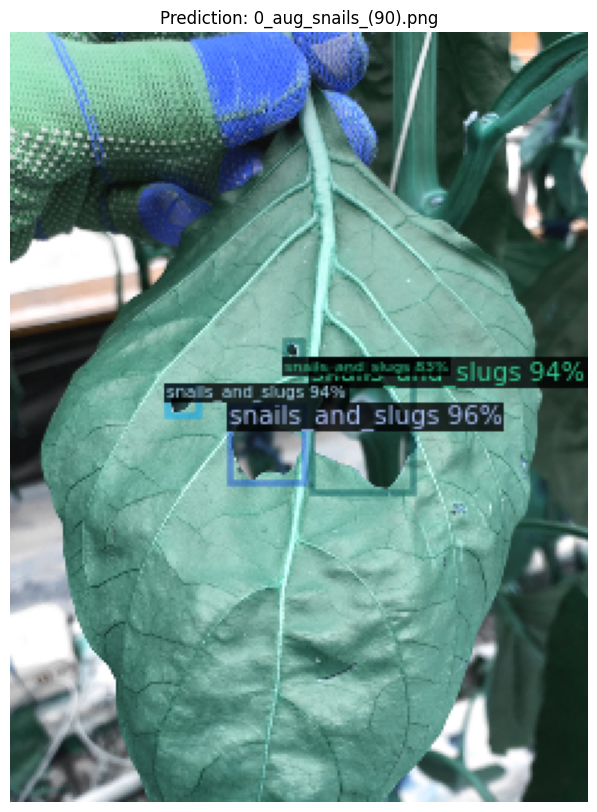

In [11]:
from detectron2.engine import DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
import random

# ==========================================
# 1. LOAD THE TRAINED WEIGHTS
# ==========================================
# UPDATE THIS PATH to wherever your model_final.pth is located
cfg.MODEL.WEIGHTS = "/kaggle/input/notebooks/tijesu26/paprika-ddl-implementation/output/naive_ddl/model_final.pth" 

# Set a threshold: only display predictions the model is at least 50% confident about
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   

# Create the predictor object using your trained weights
predictor = DefaultPredictor(cfg)


# ==========================================
# 2. QUANTITATIVE EVALUATION (mAP Score)
# ==========================================
print("Running Quantitative Evaluation (mAP)...")
evaluator = COCOEvaluator("paprika_valid", output_dir=OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "paprika_valid")

# This will print out a table with your AP, AP50, AP75 scores
evaluation_results = inference_on_dataset(predictor.model, val_loader, evaluator)
print(evaluation_results)


# ==========================================
# 3. QUALITATIVE VISUALIZATION (See the boxes!)
# ==========================================
print("\nVisualizing Predictions on Validation Data...")
val_dataset = DatasetCatalog.get("paprika_valid")

# Pick 3 random images from the validation set
for d in random.sample(val_dataset, 3):    
    im = cv2.imread(d["file_name"])
    
    # Run the model on the image
    outputs = predictor(im)
    
    # Draw the predictions
    v = Visualizer(im[:, :, ::-1],
                   metadata=MetadataCatalog.get("paprika_valid"), 
                   scale=0.5)
    
    # Adjust text size to be readable
    v._default_font_size = 15 
    
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(out.get_image()[:, :, ::-1])
    plt.title(f"Prediction: {os.path.basename(d['file_name'])}")
    plt.axis("off")
    plt.show()